# Titanic Survival Prediction

## Introduction

The Titanic disaster is one of the most famous events in history. On April 15, 1912, the ship sank after hitting an iceberg during its first journey. Many people lost their lives, but some survived.

In this project, I will try to understand:
> **What type of passengers were more likely to survive?**

This is a `Binary classification problem`, where the output is:
- 1 → Survived  
- 0 → Not Survived  

To solve this, I will use `Logistic Regression`, which is simple, fast, and easy to interpret.

---

## Objective

The main goal of this project is to build a machine learning model that can predict whether a passenger survived or not based on available features.

---

## Project Workflow

I will follow these steps in this project:

1. Data Loading  
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing 
5. Feature Engineering  
6. Train-Test Split  
7. Model Building (Logistic Regression)  
8. Model Evaluation  

---

## Understanding the Dataset

The dataset contains information about passengers, such as:
- Age  
- Gender  
- Ticket Fare  
- Passenger Class  
- Family Members  
- Embarkation Port  

These features will help us understand survival patterns.

---

## ❓ Questions to Explore

During the analysis, I will try to answer the following questions:

- How should missing values be handled? 
- What is the overall survival rate? Did gender affect survival chances?
- Did passenger class influence survival?  
- Did traveling with family matter?  
- Did the embarkation port have any effect?  
- Is there a relationship between fare and survival?  
- Which features are most important?  

---


# Import Dependencies 

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Data Collection & Processing

In [3]:
# Load CSV file
df = pd.read_csv("Titanic-Dataset.csv")

In [4]:
# Overview of dataset
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [6]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
347,348,1,3,"Davison, Mrs. Thomas Henry (Mary E Finck)",female,NaN,1,0,386525,16.1000,NaN,S
497,498,0,3,"Shellard, Mr. Frederick William",male,NaN,0,0,C.A. 6212,15.1000,NaN,S
213,214,0,2,"Givard, Mr. Hans Kristensen",male,30.0,0,0,250646,13.0000,NaN,S
247,248,1,2,"Hamalainen, Mrs. William (Anna)",female,24.0,0,2,250649,14.5000,NaN,S
793,794,0,1,"Hoyt, Mr. William Fisher",male,NaN,0,0,PC 17600,30.6958,NaN,C


## Data Dictionary

| Variable      | Definition                                      | Key / Notes |
|---------------|--------------------------------------------------|-----------|
| **PassengerId** | Unique identifier for each passenger            | -         |
| **Survived**  | Survival status                                 | 0 = No, 1 = Yes |
| **Pclass**    | Ticket class (Passenger Class)                  | 1 = 1st (Upper), 2 = 2nd (Middle), 3 = 3rd (Lower) |
| **Name**      | Passenger's full name                           | - |
| **Sex**       | Gender of the passenger                         | male / female |
| **Age**       | Age in years                                    |  |
| **SibSp**     | Number of siblings / spouses aboard             | - |
| **Parch**     | Number of parents / children aboard             | - |
| **Ticket**    | Ticket number                                   | - |
| **Fare**      | Passenger fare (in pounds)                      | - |
| **Cabin**     | Cabin number                                    | -  |
| **Embarked**  | Port of Embarkation                             | C = Cherbourg, Q = Queenstown, S = Southampton |


In [7]:
# Number of  Rows and columns
df.shape

(891, 12)

- So we have 12 columns, where 11 columns are features and one is output column with 891 rows (passenger information)

In [8]:
# Some information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
# Check number of missing values in each column
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
# null values in percentange
np.round(df.isna().mean()*100, 2)

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

From the dataset, we can observe the following:

- The `Cabin` column has a large number of missing values (around 77%), so it may not be very useful for modeling.
- The `Age` column also contains missing values (approximately 20%), which need to be handled carefully.
- The `Embarked` column has only a few missing values, so it can be easily handled.

## Handling the Missing values

In [11]:
# Drop the cabin column
df = df.drop(columns='Cabin',axis=1)

### Dropping Cabin Column

The `Cabin` column is dropped because it contains a very high number of missing values (around 77%).

Since most of the data is missing, this feature does not provide enough useful information for the model and may negatively affect performance.

In [12]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


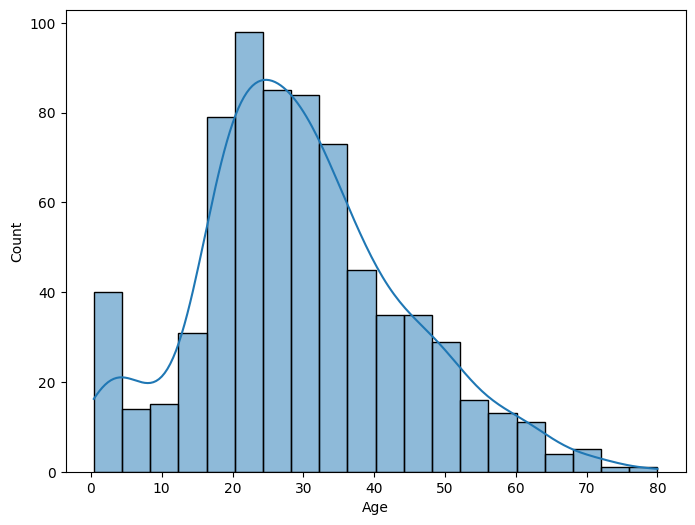

In [13]:
# Check 'Age' Column Distribution
plt.figure(figsize=(8,6))
sns.histplot(df['Age'],kde=True)
plt.show()

In [14]:
# Also Skew value
df['Age'].skew()

np.float64(0.38910778230082704)

To decide how to fill missing values in the `Age`column, I first analyzed its distribution.

- The skewness value is `0.389`, which is close to 0, indicating that the data is approximately normally distributed.
- The histogram plot also shows a roughly symmetric, bell-shaped distribution.

Based on these observations, the distribution is not significantly skewed. so, I used the `mean value` to fill the missing values in the Age column


In [15]:
# Average value of Age
avg_age = np.round(df['Age'].mean(),2)
avg_age 

np.float64(29.7)

In [16]:
# replace missing values in 'Age' column with mean value
df['Age'].fillna(avg_age, inplace=True)

C:\Users\dclid\AppData\Local\Temp\ipykernel_1556\1794995628.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(avg_age, inplace=True)


In [17]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [18]:
Emarked_mode = df['Embarked'].mode()[0]
Emarked_mode

'S'

In [19]:
# Replacing the missing values in 'Embarked' column with mode value
df['Embarked'].fillna(Emarked_mode,inplace=True)

C:\Users\dclid\AppData\Local\Temp\ipykernel_1556\465272790.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(Emarked_mode,inplace=True)


In [20]:
# Again Check null values
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

### Q1. How should missing values be handled?
Missing values should be handled based on importance of the feature and the percentage of missing data.
- If a column has too many missing values (e.g., Cabin), it is better to drop it.
- For numerical columns like Age, missing values can be filled using mean or median.
- For categorical columns like Embarked, missing values can be filled using the most frequent value (mode).


# Data Analysis (EDA)

In [21]:
# get some statistical information
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699293,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.700000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [22]:
# Number of people survived or not survived
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

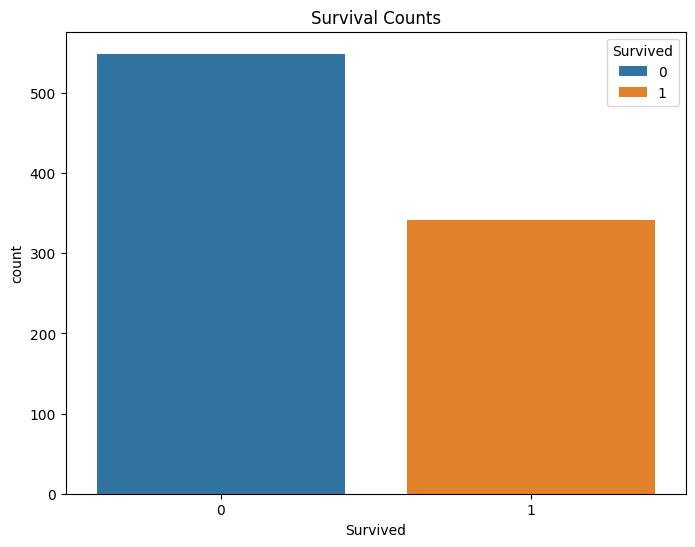

In [23]:
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='Survived', hue='Survived')
plt.title("Survival Counts")
plt.show()

In [24]:
# survival rate 
np.round(df['Survived'].mean()*100,2)

np.float64(38.38)

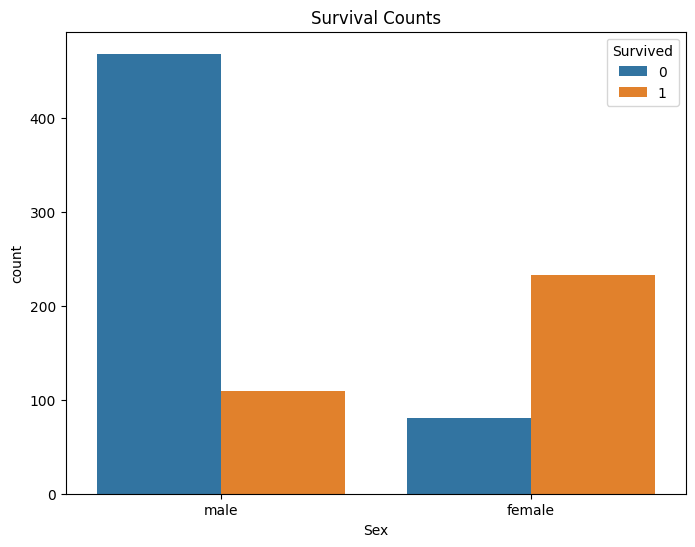

In [25]:
# Survived people according to 'sex' column
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title("Survival Counts")
plt.show()

In [26]:
# survival rate by 'sex'
np.round(df.groupby('Sex')['Survived'].mean()*100,2)

Sex
female    74.20
male      18.89
Name: Survived, dtype: float64

In [27]:
# number of people survive according to gender('Sex') column
df.groupby('Sex')['Survived'].value_counts()

Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

## Q2. What is the overall survival rate? Did gender affect survival chances?
Titanic Survival Analysis Summary:
- The overall survival rate of passengers is 38.38%, meaning less than half of the passengers survived.
- When analyzed by gender:
  - The survival rate for males is 18.89%, which is significantly low.
  - The survival rate for females is 74.20%, which is considerably high.

This clearly indicates a strong relationship between gender and survival, where females had a much higher chance of survival compared to males.

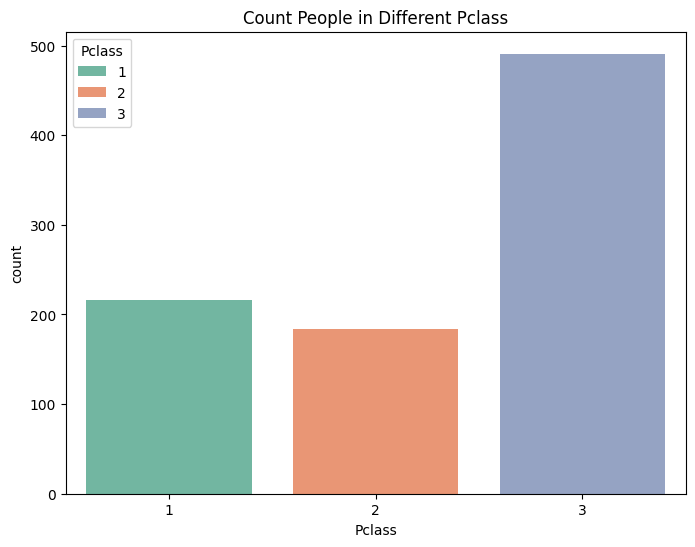

In [28]:
# Count plot of Pclass
plt.figure(figsize=(8,6))
sns.countplot(data=df , x='Pclass', hue='Pclass',palette='Set2')
plt.title("Count People in Different Pclass")
plt.show()

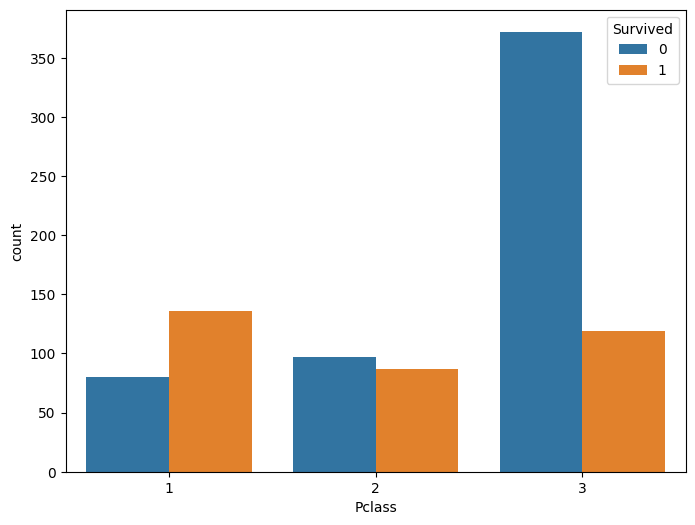

In [29]:
# number of survivors according to 'Pclass'
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.show()

In [30]:
# find servivors rate in 'Pclass'
np.round(df.groupby('Pclass')['Survived'].mean()*100, 2)

Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64

## Q3. Did passenger class influence survival?
Yes, passenger class influences survival rate.
 - Passenger class has a significant influence on survival rate.
 - Passengers traveling in Pclass 1 (Upper Class) had the highest survival rate, indicating better chances of survival.
 - In Pclass 2 (Middle Class), the survival rate is approximately 47.28%, showing moderate survival chances.
 - In contrast, passengers in Pclass 3 (Lower Class) had the lowest survival rate of 24.24%, meaning most of them did not survive.

Overall, survival probability decreases as passenger class goes from 1st to 3rd.

In [31]:
# create a new column 'Family_size' with add 'SibSp' and 'Parch'
df['Family_size'] = df['SibSp'] + df['Parch']

In [32]:
# drop SibSp and Parch columns
df.drop(columns=['SibSp','Parch'], inplace=True)

In [33]:
df['Family_size'].unique()

array([ 1,  0,  4,  2,  6,  5,  3,  7, 10])

In [34]:
# create new column 'FamilyGroup' according to family size
df['FamilyGroup'] = pd.cut(
    df['Family_size'],
    bins=[-1, 0, 3, 10],
    labels=['Alone', 'Small', 'Large']
)

In [35]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Family_size,FamilyGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,A/5 21171,7.2500,S,1,Small
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,PC 17599,71.2833,C,1,Small
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,STON/O2. 3101282,7.9250,S,0,Alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,113803,53.1000,S,1,Small
4,5,0,3,"Allen, Mr. William Henry",male,35.0,373450,8.0500,S,0,Alone


In [36]:
# find survival rate for different family size
np.round(df.groupby('FamilyGroup')['Survived'].mean()*100, 2)

C:\Users\dclid\AppData\Local\Temp\ipykernel_1556\422355635.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  np.round(df.groupby('FamilyGroup')['Survived'].mean()*100, 2)


FamilyGroup
Alone    30.35
Small    57.88
Large    16.13
Name: Survived, dtype: float64

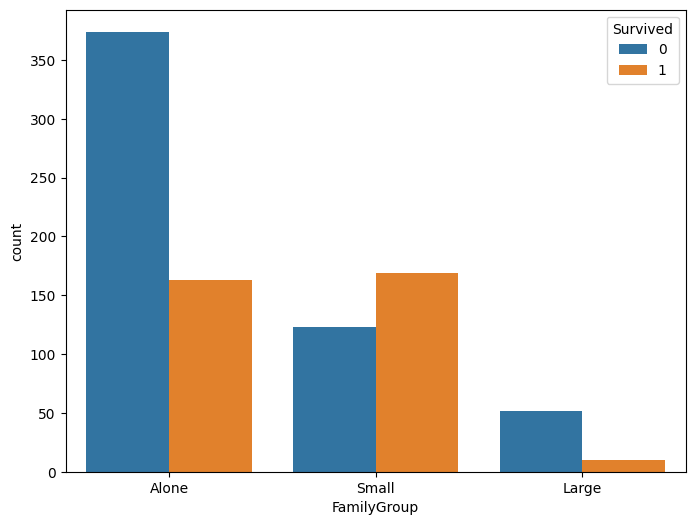

In [37]:
# number of survivors according to 'FamilySize'
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='FamilyGroup', hue='Survived')
plt.show()

## Q4. Did traveling with family matter?
Yes, travelling with family clearly mattered.

Passengers travelling in small families had the highest survival rate (57.88%), while those travelling alone had much lower survival (30.35%), and large families had the worst survival rate (16.13%).

In [38]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Family_size,FamilyGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,A/5 21171,7.2500,S,1,Small
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,PC 17599,71.2833,C,1,Small
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,STON/O2. 3101282,7.9250,S,0,Alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,113803,53.1000,S,1,Small
4,5,0,3,"Allen, Mr. William Henry",male,35.0,373450,8.0500,S,0,Alone


In [39]:
# Embarked effect on survivors rate
np.round(df.groupby('Embarked')['Survived'].mean()*100, 2)

Embarked
C    55.36
Q    38.96
S    33.90
Name: Survived, dtype: float64

In [40]:
# value counts for different place 
df['Embarked'].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

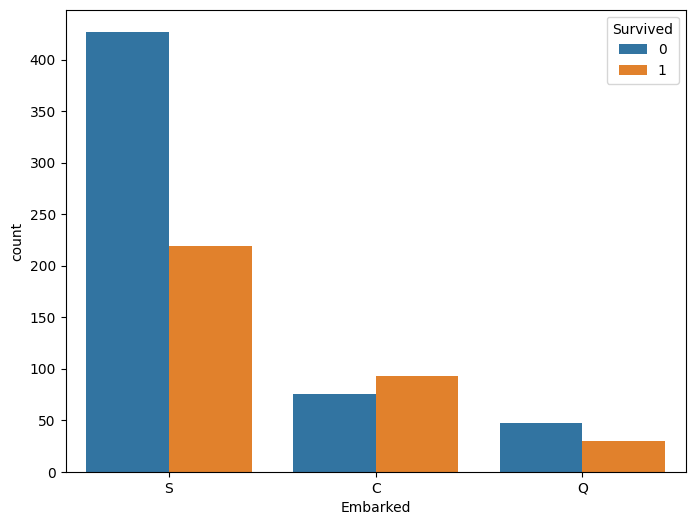

In [41]:
# number of survivors according to 'Embarked'
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='Embarked', hue='Survived')
plt.show()

In [42]:
df.groupby('Pclass')['Embarked'].value_counts()

Pclass  Embarked
1       S           129
        C            85
        Q             2
2       S           164
        C            17
        Q             3
3       S           353
        Q            72
        C            66
Name: count, dtype: int64

## Q5. Did the embarkation port have any effect?
Although survival rates differ across embarkation ports, this does not indicate that the port itself directly affects survival. Instead, the differences are likely due to underlying factors such as passenger class distribution and socioeconomic status. Therefore, embarkation port is not a strong independent predictor of survival, but it indirectly reflects class-related differences.

In [43]:
# Grouping the data by survival status 
df.groupby('Survived')['Fare'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
Survived,,,,
0,22.117887,10.5,0.0,263.0000
1,48.395408,26.0,0.0,512.3292


In [44]:
# statistical summary of 'Survived' and 'Fare' columns
df[['Survived','Fare']].describe()

,Survived,Fare
count,891.000000,891.000000
mean,0.383838,32.204208
std,0.486592,49.693429
min,0.000000,0.000000
25%,0.000000,7.910400
50%,0.000000,14.454200
75%,1.000000,31.000000
max,1.000000,512.329200


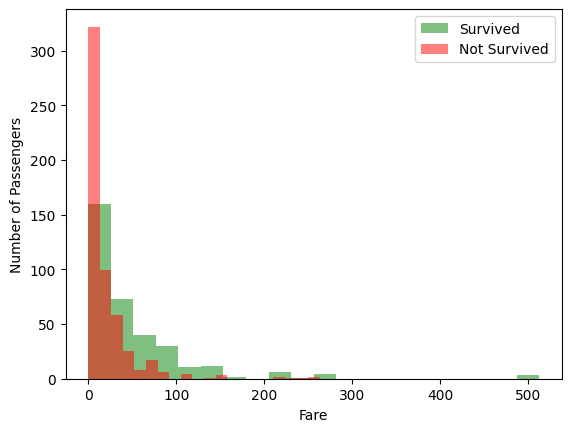

In [45]:
# get numbers of surviver according to 'Fare' value
plt.hist(df[df['Survived']==1]['Fare'], bins=20, alpha=0.5, label='Survived',color='green')
plt.hist(df[df['Survived']==0]['Fare'], bins=20, alpha=0.5, label='Not Survived',color='red')

plt.xlabel('Fare')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()

In [46]:
# Check average Fare values in different Pclass
df.groupby('Pclass')['Fare'].mean()

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

## Q6. Is there a relationship between fare and survival?
Yes, there is a relationship between fare and survival, but it is indirect.

Higher fare passengers had higher survival rates, but this is mainly because fare is strongly linked with passenger class (Pclass), not because fare alone determines survival.

# Data Preprocessing For Model Eavluation

### Label Encoding on `Sex` Column 

Label Encoding converts categorical values into numeric form.

#### Example:
`Sex` column values:
- male
- female

After Label Encoding:
- male → 1
- female → 0

In [47]:
# import LabelEncoder
from sklearn.preprocessing import LabelEncoder

In [48]:
# label Encoder
le = LabelEncoder()

In [49]:
df['Sex']=le.fit_transform(df['Sex'])
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Family_size,FamilyGroup
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,A/5 21171,7.2500,S,1,Small
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,PC 17599,71.2833,C,1,Small
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,STON/O2. 3101282,7.9250,S,0,Alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,113803,53.1000,S,1,Small
4,5,0,3,"Allen, Mr. William Henry",1,35.0,373450,8.0500,S,0,Alone


### One-Hot Encoding on `Embarked` Column

One-Hot Encoding converts categorical values into separate binary columns.

#### Example:
`Embarked` column values:
- S (Southampton)
- C (Cherbourg)
- Q (Queenstown)

After One-Hot Encoding:

| Embarked | Embarked_C | Embarked_Q | Embarked_S |
|----------|------------|------------|------------|
| S        | 0          | 0          | 1          |
| C        | 1          | 0          | 0          |
| Q        | 0          | 1          | 0          |

In [50]:
# import One-Hot Encoder
from sklearn.preprocessing import OneHotEncoder

In [51]:
ohe = OneHotEncoder(sparse_output=False)

encoded = ohe.fit_transform(df[['Embarked']])

In [52]:
# Find new columns after apply encoding 
columns = ohe.get_feature_names_out(['Embarked'])

In [53]:
# create new dataframe with encoding columns and values
encoding_df = pd.DataFrame(
encoded,
columns=columns
)

In [54]:
encoding_df.head()

,Embarked_C,Embarked_Q,Embarked_S
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0


In [55]:
# concate new dataframe with original dataframe
df = pd.concat([df, encoding_df], axis=1)

In [56]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Family_size,FamilyGroup,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,A/5 21171,7.2500,S,1,Small,0.0,0.0,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,PC 17599,71.2833,C,1,Small,1.0,0.0,0.0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,STON/O2. 3101282,7.9250,S,0,Alone,0.0,0.0,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,113803,53.1000,S,1,Small,0.0,0.0,1.0
4,5,0,3,"Allen, Mr. William Henry",1,35.0,373450,8.0500,S,0,Alone,0.0,0.0,1.0


In [57]:
# remove unnecessary columns
df.drop(columns=['PassengerId','Embarked','Name','Ticket'], axis=1, inplace=True)

In [58]:
df.head()

,Survived,Pclass,Sex,Age,Fare,Family_size,FamilyGroup,Embarked_C,Embarked_Q,Embarked_S
0,0,3,1,22.0,7.2500,1,Small,0.0,0.0,1.0
1,1,1,0,38.0,71.2833,1,Small,1.0,0.0,0.0
2,1,3,0,26.0,7.9250,0,Alone,0.0,0.0,1.0
3,1,1,0,35.0,53.1000,1,Small,0.0,0.0,1.0
4,0,3,1,35.0,8.0500,0,Alone,0.0,0.0,1.0


## Data Separate 

In [59]:
# Separate features & output column
X = df.drop(columns=['Survived','FamilyGroup'])
y = df['Survived']

In [60]:
X.shape, y.shape

((891, 8), (891,))

## Splitting Training & Testing data

In [61]:
# Split data into training & testing part
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=2)

In [62]:
# Chaek Shape of those set 
X_train.shape, y_train.shape

((712, 8), (712,))

In [64]:
X_test.shape,y_test.shape

((179, 8), (179,))

# About Logistic Regression

## What is Logistic Regression?
Logistic Regression is a supervised machine learning algorithm used for classification problems.  
It predicts the probability of a categorical outcome, usually binary (0/1, Yes/No).

## Why is it used?
We use Logistic Regression when:
- The output variable is categorical
- We need probability-based predictions
- The problem is a classification task

## How it works?
1. Takes input features
2. Applies linear combination of inputs
3. Uses Sigmoid function to convert output into probability (0 to 1)
4. Applies threshold (usually 0.5) to classify output

## What is Sigmoid Function?
The sigmoid function is a mathematical function used in Logistic Regression to map any real-valued number into a value between 0 and 1.

## Formula
σ(x) = 1 / (1 + e^(-x))

## Output Interpretation
- If probability > 0.5 → Class = 1
- If probability ≤ 0.5 → Class = 0

## Model Trainning

In [65]:
# Model create 
model = LogisticRegression()

In [66]:
# Model trainning 
model.fit(X_train, y_train)

H:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# Model Evaluation

In [74]:
# predict value
y_pred = model.predict(X_test)

In [75]:
# model accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy}")

Accuracy Score: 0.7821229050279329


In [76]:
# Confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[89 11]
 [28 51]]


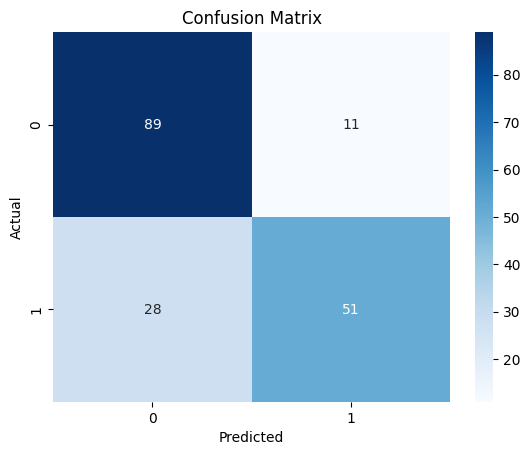

In [77]:
# visualization of confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Confusion Matrix Interpretation

The confusion matrix is:

[[89 11]
 [28 51]]

- True Negative (89): Correctly predicted passengers who did not survive
- False Positive (11): Predicted survived but actually did not survive
- False Negative (28): Predicted did not survive but actually survived
- True Positive (51): Correctly predicted passengers who survived

The model performs well in predicting non-survivors, but it makes more errors in predicting survivors, as seen from the higher false negatives.

Overall accuracy is around 78%, but the model tends to misclassify some actual survivors.

In [84]:
# find Coefficient learn by the model
model.coef_[0] 

array([-0.99218806, -2.64029794, -0.04390402,  0.0031228 , -0.23160947,
        0.8867953 ,  0.97171606,  0.56679275])

- `model.coef_` : This stores the coefficients (weights) learned by the model

In [85]:
# Find impactfull features on trainning data
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})

feature_importance = feature_importance.sort_values(by='Coefficient', ascending=False)

print(feature_importance)

       Feature  Coefficient
6   Embarked_Q     0.971716
5   Embarked_C     0.886795
7   Embarked_S     0.566793
3         Fare     0.003123
2          Age    -0.043904
4  Family_size    -0.231609
0       Pclass    -0.992188
1          Sex    -2.640298


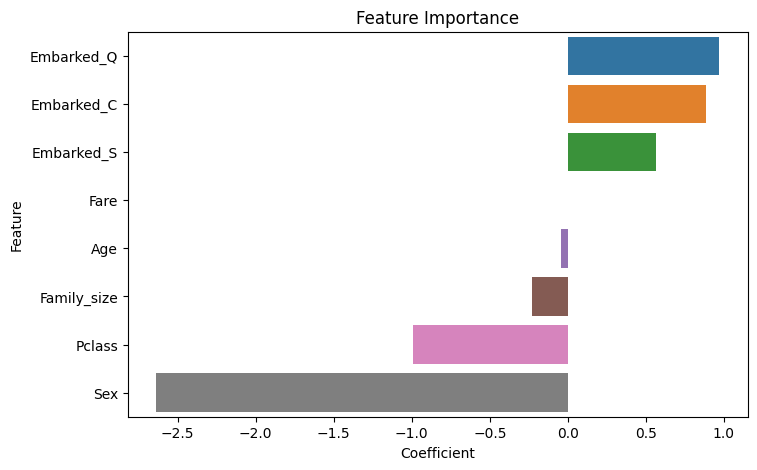

In [88]:
plt.figure(figsize=(8,5))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance, hue='Feature')
plt.title("Feature Importance")
plt.show()

## Feature Importance Analysis

Based on Logistic Regression coefficients, feature importance is determined by the magnitude of coefficients.

The most important feature is:
- Sex: It has the highest coefficient magnitude, indicating strong influence on survival.

Other important features include:
- Pclass
- Embarked (Q, C, S)

Less important features:
- Family_size
- Age

Least important feature:
- Fare, as its coefficient is close to zero

This indicates that gender and passenger class played the most significant role in survival prediction.

## Model Performance Summary

| Metric                | Value |
|----------------------|------|
| Accuracy             | 78% |
| Total Predictions    | 179 |
| True Positive (TP)   | 51 |
| True Negative (TN)   | 89 |
| False Positive (FP)  | 11 |
| False Negative (FN)  | 28 |

**MD Siyam Hossain**  
*Data Analyst | Machine Learning | Deep Learning | AI Agent Enthusiast*